In [1]:
import numpy as np
import glob
import torch
import json
import torch.nn.functional as F
import nibabel as nib
import huggingface_hub


from matplotlib import pyplot as plt
from PIL import Image

from modeling.BaseModel import BaseModel
from modeling import build_model
from utilities.distributed import init_distributed
from utilities.arguments import load_opt_from_config_files
from utilities.constants import BIOMED_CLASSES


from inference_utils.inference import interactive_infer_image
from inference_utils.output_processing import dice_volume, iou_volume, hausdorff_distance_volume
from inference_utils.processing_utils import read_nifti_only, process_intensity_image, resize_to_original

c:\Users\P095392\GitProjects\BiomedParse\bio_med_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Deformable Transformer Encoder is not available.


c:\Users\P095392\GitProjects\BiomedParse\bio_med_venv\Lib\site-packages\kornia\feature\lightglue.py:30: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
c:\Users\P095392\GitProjects\BiomedParse\bio_med_venv\Lib\site-packages\transformers\utils\generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [2]:
with open('tokens.json') as f:
    tokens = json.load(f)

In [3]:
HF_TOKEN = tokens['hugging_face']

huggingface_hub.login(HF_TOKEN)

Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: read).
Your token has been saved to C:\Users\P095392\.cache\huggingface\token
Login successful


### Model Setup

In [4]:
opt = load_opt_from_config_files(["configs/biomedparse_inference.yaml"])
opt = init_distributed(opt)

# Load model from pretrained weights
pretrained_pth = 'pretrained/biomed_parse.pt'
pretrained_pth = 'hf_hub:microsoft/BiomedParse'

model = BaseModel(opt, build_model(opt)).from_pretrained(pretrained_pth).eval().cuda()
with torch.no_grad():
    model.model.sem_seg_head.predictor.lang_encoder.get_text_embeddings(BIOMED_CLASSES + ["background"], is_eval=True)


c:\Users\P095392\GitProjects\BiomedParse\bio_med_venv\Lib\site-packages\transformers\utils\generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
$UNUSED$ criterion.empty_weight, Ckpt Shape: torch.Size([17])


### Utility Functions

In [10]:
!pip install pydicom nibabel SimpleITK


def inference_nifti(file_path, text_prompts, is_CT, site=None):
    image, nii = read_nifti_only(file_path)
    test_3D = np.empty((1, image.shape[0], image.shape[1]))

    for slice_iter in range(image.shape[2]):
        
        # Resize and padding
        image_array = process_intensity_image(image[: ,: , slice_iter], is_CT, site)
        # Get prediction
        pred_mask = interactive_infer_image(model, Image.fromarray(image_array), text_prompts)

        # im = Image.fromarray((pred_mask[0]*255).astype(np.uint8))
        # im.save(f"pred_masks\slice_{slice_iter}.png")

        # Resize to original size
        resize_image = resize_to_original(pred_mask, image.shape[0], image.shape[1])

        # Stack back together
        test_3D = np.vstack((test_3D, resize_image))

    print(f"Patient {file_path[14:20]} is complete")

    # Remove inital empty row
    test_3D = np.delete(test_3D, (0), axis=0)

    final_img = nib.Nifti1Image(test_3D.transpose(1,2,0), nii)
    nib.save(final_img, f'results/CT_patient_{file_path[14:20]}.nii.gz')

    return test_3D



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
img_paths = 'data//CT//img//*'
is_CT = True
site = 'abdomen'
text_prompts = ['pancreatic tumor']

for img_path in glob.iglob(img_paths):
    # The result predictions are soft, hence why he thresholds 0.5 to set make them 0-1
    image =  inference_nifti(img_path, text_prompts, is_CT=is_CT, site=site)

Patient 100456 is complete


In [26]:
patients = []

for img_path in glob.iglob('data//CT//img//*'):
    # TODO add regex for stricter selection
    patients.append(img_path[14:20])

len(patients)

514

In [13]:
patients[0]

'100033'

In [27]:
# For single file test
# patients = ['100000']
"""
TODO:  Make the calculations on CUDA instead of cpu
"""

dice_scores = []
iou_scores = []
HD_scores = []

patients_n = 0
# [231:423]
for patient in patients[231:423]:

    path_label = f'data//CT//gt//{patient}_00001.nii.gz'
    label, nii = read_nifti_only(path_label)

    # One hot encode multiple classes
    unique_labels = np.unique(label)
    print(unique_labels)
    label_one_hot = F.one_hot(torch.tensor(label).long(), num_classes=-1)
    print(np.unique(label_one_hot[:,:,:,1]))
    # print("Unique values currently are :", torch.unique(label_one_hot))

    path_pred = f'results//CT_patient_{patient}.nii.gz'
    pred, nii = read_nifti_only(path_pred)

    pred = torch.tensor(pred)
    # Threshold soft predictions to hard, same as the writer
    pred = (pred > 0.5).float()

    # 1 is currently PDAC lessions, watch out for which label we are calculating
    if 1 not in unique_labels:
         continue
    else:
        print(patient, label_one_hot.shape)
        dice = dice_volume(torch.permute(label_one_hot[:,:,:,1], (2, 0, 1)), torch.permute(pred, (2, 0, 1)))
        iou = iou_volume(torch.permute(label_one_hot[:,:,:,1], (2, 0, 1)), torch.permute(pred, (2, 0, 1)))
        hausdorff = hausdorff_distance_volume(torch.permute(label_one_hot[:,:,:,1], (2, 0, 1)), torch.permute(pred, (2, 0, 1)))

        dice_scores.append(dice)
        iou_scores.append(iou)
        HD_scores.append(hausdorff)

        with open("metrics_baseline.txt", "a") as f:
            f.write(f"3D_DICE score for patient {patient} is : {dice.mean():05.3f}\n")
            f.write(f"3D_IoU score for patient {patient} is : {iou.mean():05.3f}\n")
            f.write(f"3D_HD score for patient {patient} is : {hausdorff}\n")
            f.write("\n")
# with open("final_avg.txt", "a") as f:
#         f.write(f"Dice average over 389 patients is: {np.average(dice_scores)}\n")
#         f.write(f"IoU average over 389 patients is: {np.average(iou_scores)}\n")
#         f.write(f"HD average over 389 patients is: {np.average(HD_scores)}\n")

[0. 2. 3. 4. 5. 6.]
[0]
[0. 1. 2. 3. 4. 5. 6.]
[0 1]
100265 torch.Size([512, 512, 218, 7])
[0. 1. 2. 3. 4. 5. 6.]
[0 1]
100266 torch.Size([512, 512, 97, 7])
[0. 1. 2. 3. 4. 5. 6.]
[0 1]
100267 torch.Size([512, 512, 97, 7])
[0. 2. 3. 4. 5. 6.]
[0]
[0. 2. 3. 4. 5. 6.]
[0]
[0. 2. 3. 4. 5. 6.]
[0]
[0. 2. 3. 4. 6.]
[0]
[0. 2. 3. 4. 5. 6.]
[0]
[0. 2. 3. 4. 5. 6.]
[0]
[0. 2. 3. 4. 5. 6.]
[0]
[0. 1. 2. 3. 4. 5. 6.]
[0 1]
100275 torch.Size([512, 512, 225, 7])
[0. 1. 2. 3. 4. 5. 6.]
[0 1]
100276 torch.Size([512, 512, 681, 7])
[0. 2. 3. 4. 6.]
[0]
[0. 1. 2. 3. 4. 5. 6.]
[0 1]
100278 torch.Size([512, 512, 97, 7])
[0. 2. 3. 4. 5. 6.]
[0]
[0. 2. 3. 4. 5. 6.]
[0]
[0. 2. 3. 4. 5. 6.]
[0]
[0. 2. 3. 4. 5. 6.]
[0]
[0. 2. 3. 4. 5. 6.]
[0]
[0. 2. 3. 4. 5. 6.]
[0]
[0. 1. 2. 3. 4. 5. 6.]
[0 1]
100285 torch.Size([512, 512, 502, 7])
[0. 2. 3. 4. 5. 6.]
[0]
[0. 2. 3. 4.]
[0]
[0. 2. 3. 4. 5. 6.]
[0]
[0. 2. 3. 4. 6.]
[0]
[0. 1. 2. 3. 4. 5. 6.]
[0 1]
100290 torch.Size([512, 512, 816, 7])
[0. 2. 3. 4. 5. 6.]
[0]
[0

EOFError: Compressed file ended before the end-of-stream marker was reached

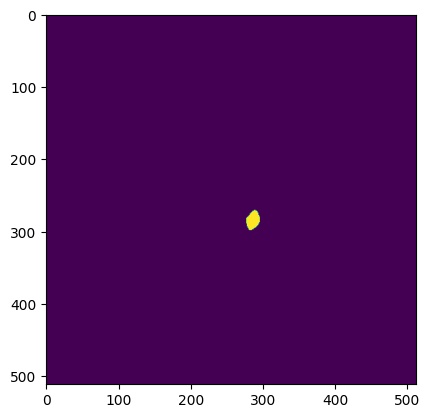

In [7]:
imgplot = plt.imshow(torch.permute(label_one_hot, (2,3,0,1))[52, 2, :, :])
plt.show()

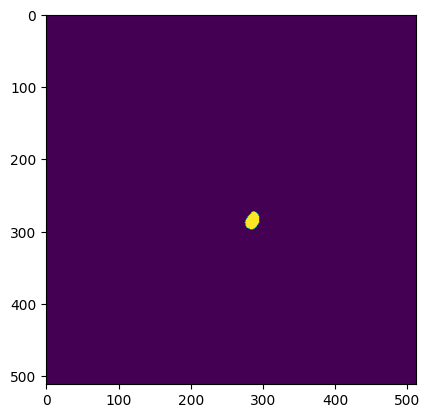

In [8]:
imgplot = plt.imshow(torch.permute(pred, (2, 0, 1))[52])
plt.show()